# SEAM CSM: AGFT vs mpra-LegNet (3 high seqs)

The CSM (Mechanism Summary Matrix) is the per-cluster × per-position **entropy** of the mutant
sequences within each SEAM cluster — low entropy at a position means that mechanism conserves
that base. Needs no model and no attributions, only the mutant one-hots + saved `cluster_labels`.

Both MSMs are computed over the variable region `insert[15:215]` (200 bp) so they line up.
AGFT: 100k mutants / 50 clusters (ref at row 0). LegNet: 25k mutants / 30 clusters,
clustered on `concat([WT, mutants[:24999]])` — reproduced here to match the labels.

Kernel: `hippo-agft` or the `SEAM_venv` python (only needs numpy/h5py/matplotlib).

In [1]:
# setup: paths (koo only), config, and the model-free MSM/loader helpers.
import numpy as np, h5py, matplotlib.pyplot as plt
from pathlib import Path

R        = Path("/grid/koo/home/pmantill/projects/SEAM_validate")
AGFT_FG  = R / "results/single_seq/foregrounds"
AGFT_MUT = R / "results/single_seq/mutagenesis_lib"
LEGNET   = R / "attribution_align/legnet_maps"
OUT      = R / "attribution_align/results"; OUT.mkdir(parents=True, exist_ok=True)

VAR_START, VAR_END = 15, 215                      # variable region within the 230 bp insert

# (display name, AGFT stem, LegNet dir -- note the LegNet trailing colon)
SEQS = [
    ("peak26256",          "peak26256",          "peak26256"),
    ("peak84030",          "peak84030",          "peak84030"),
    ("peak27535_Reversed", "peak27535_Reversed", "peak27535_Reversed:"),
]

def msm_entropy(seqs_oh, labels):
    """(N,230,4) one-hots aligned to labels (N,) -> (n_clusters,200) entropy, sorted by cluster size."""
    s = seqs_oh[:, VAR_START:VAR_END, :].astype(np.float32)   # (N,200,4)
    clusters = np.unique(labels)
    ent   = np.zeros((len(clusters), s.shape[1]), np.float32)
    sizes = np.zeros(len(clusters), int)
    for i, c in enumerate(clusters):
        m = labels == c
        sizes[i] = m.sum()
        freqs = s[m].mean(0).T                                # (4,L) mean one-hot = base frequency
        with np.errstate(divide="ignore", invalid="ignore"):
            e = -np.sum(freqs * np.log2(freqs + 1e-10), axis=0)
        ent[i] = np.nan_to_num(e)
    order = np.argsort(-sizes)                                # largest (background) cluster first
    return ent[order], sizes[order]

def load_agft(stem):
    labels = np.load(AGFT_FG / stem / "cluster_labels.npy")
    with h5py.File(AGFT_MUT / f"{stem}.h5") as f:
        seqs = f["sequences"][:]                              # (N,230,4), ref at row 0 (ref_idx=0)
    return seqs[: len(labels)], labels                        # aligned directly

def load_legnet(dirname):
    d = LEGNET / dirname
    labels = np.load(d / "cluster_labels.npy")
    with h5py.File(d / "mutagenesis.h5") as f:
        muts = f["sequences"][:]                              # (25000,230,4) mutants only
        wt   = f["wt_sequence"][:]                            # (230,4)
    seqs = np.concatenate([wt[None], muts[: len(labels) - 1]], axis=0)  # match SEAM's clustered order
    return seqs, labels

wrote /grid/koo/home/pmantill/projects/SEAM_validate/attribution_align/results/csm_agft_vs_legnet.png


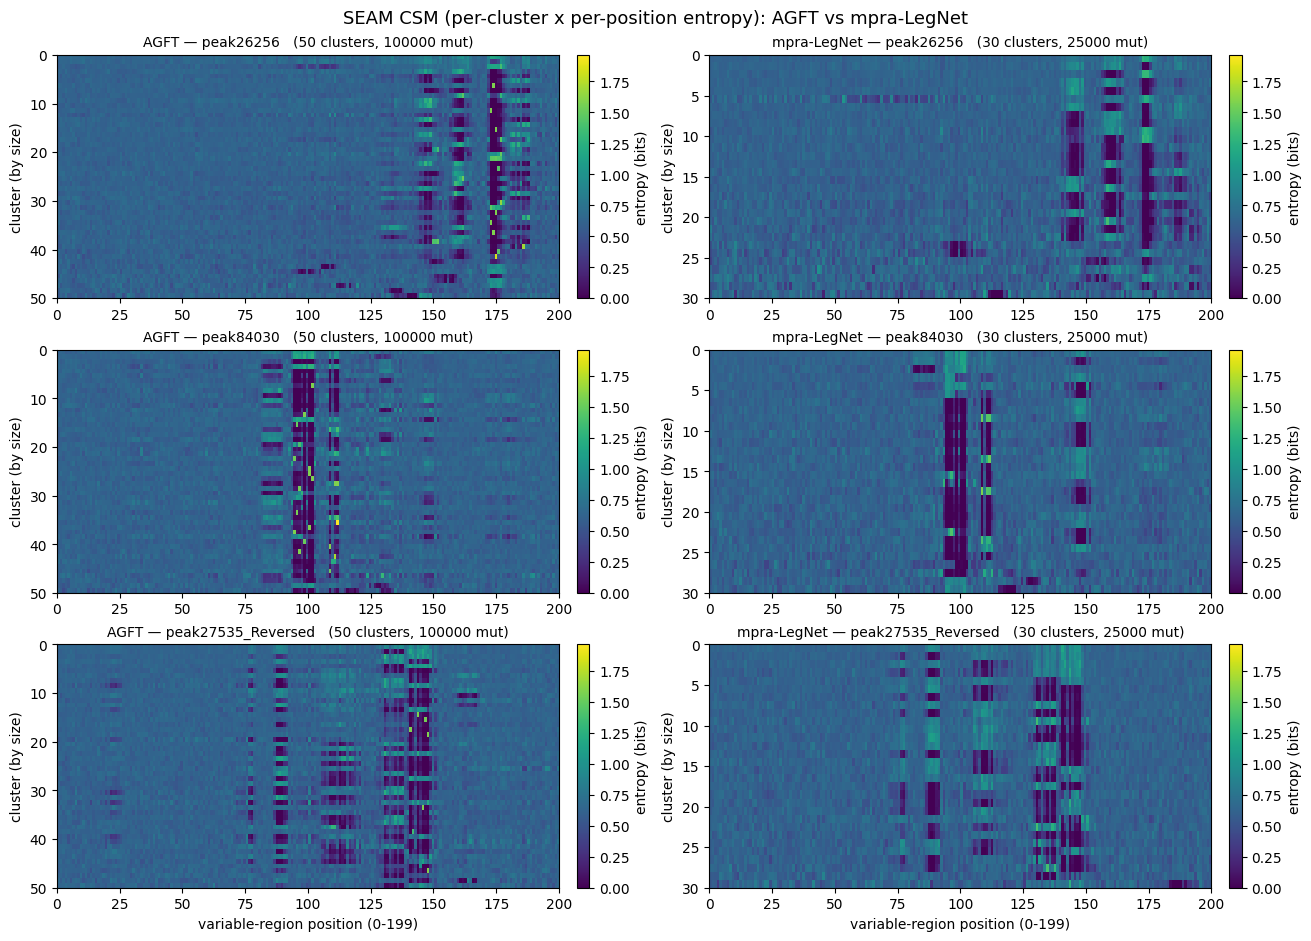

In [2]:
# CSM comparison figure: 3 seqs (rows) x AGFT vs mpra-LegNet (cols), shared entropy scale.
panels = []
for name, agft_stem, legnet_dir in SEQS:
    a_ent, a_sz = msm_entropy(*load_agft(agft_stem))
    l_ent, l_sz = msm_entropy(*load_legnet(legnet_dir))
    panels.append((name, a_ent, a_sz, l_ent, l_sz))
vmax = max(p[1].max() for p in panels) or 2.0

fig, axes = plt.subplots(len(SEQS), 2, figsize=(13, 3.1 * len(SEQS)), constrained_layout=True)
for row, (name, a_ent, a_sz, l_ent, l_sz) in enumerate(panels):
    for col, (model, ent, sz) in enumerate([("AGFT", a_ent, a_sz), ("mpra-LegNet", l_ent, l_sz)]):
        ax = axes[row, col]
        im = ax.imshow(ent, aspect="auto", cmap="viridis", vmin=0, vmax=vmax,
                       interpolation="nearest", extent=[0, ent.shape[1], ent.shape[0], 0])
        ax.set_title(f"{model} — {name}   ({ent.shape[0]} clusters, {int(sz.sum())} mut)", fontsize=10)
        ax.set_ylabel("cluster (by size)")
        if row == len(SEQS) - 1:
            ax.set_xlabel("variable-region position (0-199)")
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="entropy (bits)")
fig.suptitle("SEAM CSM (per-cluster x per-position entropy): AGFT vs mpra-LegNet", fontsize=13)
fig.savefig(OUT / "csm_agft_vs_legnet.png", dpi=300, bbox_inches="tight")
print("wrote", OUT / "csm_agft_vs_legnet.png")
plt.show()

wrote /grid/koo/home/pmantill/projects/SEAM_validate/attribution_align/results/csm_variance_profiles.png


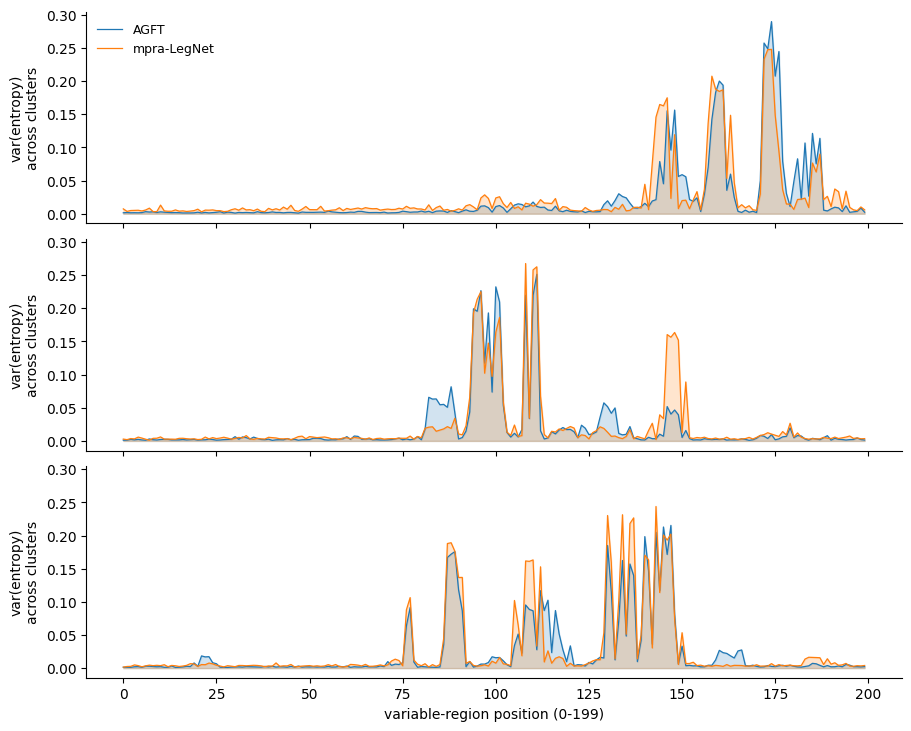

In [3]:
# CSM variability: per-position variance of entropy ACROSS clusters -> one profile per CSM.
# For each CSM (n_clusters, 200) we take var over the cluster axis at each position, giving a (200,) profile.
# Single column: AGFT and mpra-LegNet overlaid per sequence for direct comparison.
fig, axes = plt.subplots(len(SEQS), 1, figsize=(9, 2.4 * len(SEQS)),
                         sharex=True, sharey=True, constrained_layout=True)
x = np.arange(VAR_END - VAR_START)
for ax, (name, a_ent, a_sz, l_ent, l_sz) in zip(np.atleast_1d(axes), panels):
    for model, ent, color in [("AGFT", a_ent, "C0"), ("mpra-LegNet", l_ent, "C1")]:
        prof = ent.var(axis=0)                                # (200,) variance across clusters
        ax.plot(x, prof, lw=0.9, color=color, label=model)
        ax.fill_between(x, prof, alpha=0.20, color=color)
    ax.set_ylabel("var(entropy)\nacross clusters")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=9)
axes[-1].set_xlabel("variable-region position (0-199)")
fig.savefig(OUT / "csm_variance_profiles.png", dpi=300, bbox_inches="tight")
print("wrote", OUT / "csm_variance_profiles.png")
plt.show()

wrote /grid/koo/home/pmantill/projects/SEAM_validate/attribution_align/results/csm_variance_profile_corr.png


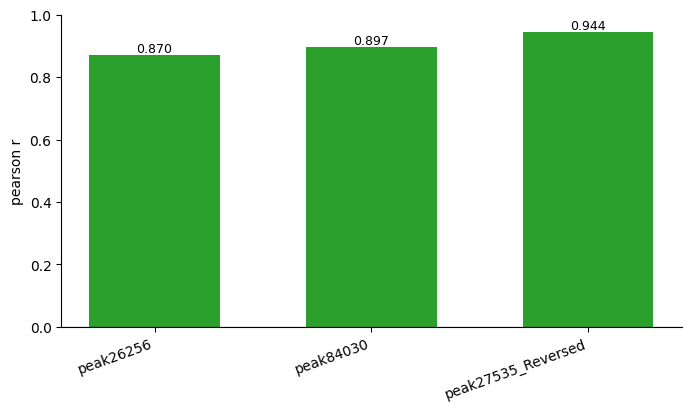

In [4]:
# Pearson r between the AGFT and mpra-LegNet variance profiles, per sequence -> barplot.
names, rs = [], []
for name, a_ent, a_sz, l_ent, l_sz in panels:
    r = np.corrcoef(a_ent.var(axis=0), l_ent.var(axis=0))[0, 1]   # r of the two (200,) profiles
    names.append(name); rs.append(r)

fig, ax = plt.subplots(figsize=(1.6 * len(names) + 2, 4), constrained_layout=True)
bars = ax.bar(names, rs, color="C2", width=0.6)
for b, r in zip(bars, rs):
    ax.text(b.get_x() + b.get_width() / 2, r, f"{r:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("pearson r")
ax.axhline(0, color="k", lw=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.savefig(OUT / "csm_variance_profile_corr.png", dpi=300, bbox_inches="tight")
print("wrote", OUT / "csm_variance_profile_corr.png")
plt.show()